<a href="https://colab.research.google.com/github/DarshiniMahesh/AI-Practice/blob/main/Object_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.0 MB/s eta 0:00:00


Step 1 — Load YOLOv11

In [ ]:
from ultralytics import YOLO

# Upgrade to YOLOv11
model = YOLO("yolo11n.pt")  # downloads automatically
print("YOLOv11 loaded!", model.info())

YOLO11n summary: 181 layers, 2,624,080 parameters, 0 gradients, 6.6 GFLOPs
YOLOv11 loaded! (181, 2624080, 0, 6.614336)


Step 2 — Camera detection with YOLOv11

In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import numpy as np
import cv2
import matplotlib.pyplot as plt

def take_photo():
    js = Javascript('''
        async function takePhoto() {
            const div = document.createElement('div');
            const capture = document.createElement('button');
            capture.textContent = '📸 Capture Frame';
            capture.style.padding = '10px 20px';
            capture.style.fontSize = '16px';
            capture.style.margin = '10px';
            capture.style.cursor = 'pointer';
            capture.style.background = '#4CAF50';
            capture.style.color = 'white';
            capture.style.border = 'none';
            capture.style.borderRadius = '8px';

            const video = document.createElement('video');
            video.style.display = 'block';
            video.style.width = '100%';
            video.style.maxWidth = '640px';
            video.style.borderRadius = '8px';
            video.setAttribute('playsinline', '');

            const stream = await navigator.mediaDevices.getUserMedia({video: true});
            document.body.appendChild(div);
            div.appendChild(video);
            div.appendChild(capture);
            video.srcObject = stream;
            await video.play();

            await new Promise((resolve) => capture.onclick = resolve);

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);

            stream.getTracks().forEach(t => t.stop());
            div.remove();

            return canvas.toDataURL('image/jpeg', 0.92);
        }
        takePhoto()
    ''')
    display(js)
    data = eval_js('takePhoto()')
    binary = b64decode(data.split(',')[1])
    img_array = np.frombuffer(binary, dtype=np.uint8)
    img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
    return img

print("Camera function ready!")

Camera function ready!


Step 3 — Capture + detect

Click the button to capture — hold your phone/object in front of camera!


<IPython.core.display.Javascript object>

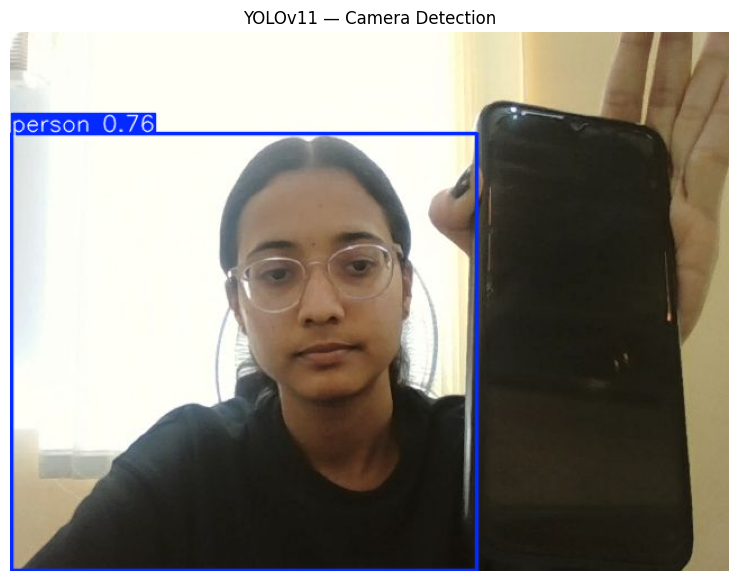


 Detected 1 object(s):

   person               → 76.2% confidence


In [ ]:
print("Click the button to capture — hold your phone/object in front of camera!")

frame = take_photo()

results = model.predict(
    source=frame,
    conf=0.35,        # slightly lower threshold = catches more objects
    iou=0.45,         # removes duplicate boxes
    save=False,
    verbose=False
)

annotated = results[0].plot(
    line_width=2,     # thicker boxes
    font_size=12
)

plt.figure(figsize=(12, 7))
plt.imshow(annotated[:, :, ::-1])
plt.axis("off")
plt.title("YOLOv11 — Camera Detection")
plt.show()

# Print detections clearly
boxes = results[0].boxes
if len(boxes) == 0:
    print("Nothing detected — try better lighting or move closer")
else:
    print(f"\n Detected {len(boxes)} object(s):\n")
    for box in boxes:
        label = model.names[int(box.cls[0])]
        conf  = float(box.conf[0])
        print(f"   {label:20s} → {conf:.1%} confidence")

Step 4 — Upload image detection

Choose an image to upload...


Saving Screenshot 2026-03-20 115328.png to Screenshot 2026-03-20 115328.png

Running YOLOv11 on: Screenshot 2026-03-20 115328.png


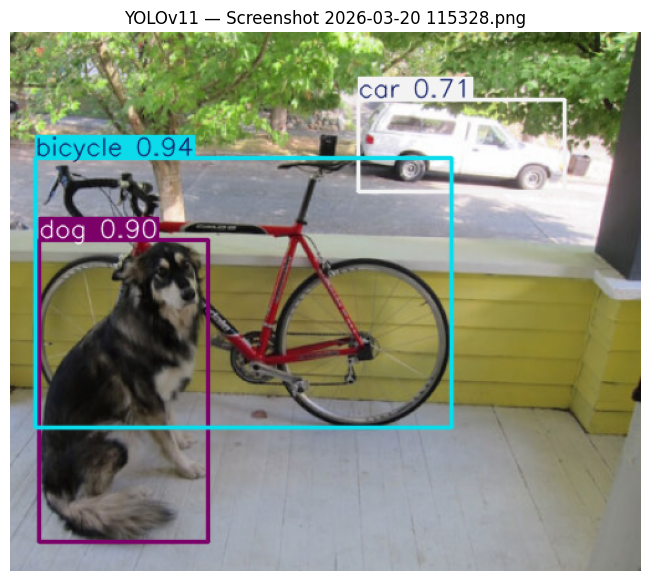


 Detected 3 object(s):

   bicycle              → 94.4% confidence
   dog                  → 90.0% confidence
   car                  → 70.8% confidence


In [ ]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("Choose an image to upload...")
uploaded = files.upload()

for filename in uploaded.keys():
    # Read uploaded image
    img_array = np.frombuffer(uploaded[filename], dtype=np.uint8)
    img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)

    print(f"\nRunning YOLOv11 on: {filename}")

    results = model.predict(
        source=img,
        conf=0.35,
        iou=0.45,
        save=False,
        verbose=False
    )

    annotated = results[0].plot(line_width=2, font_size=12)

    plt.figure(figsize=(12, 7))
    plt.imshow(annotated[:, :, ::-1])
    plt.axis("off")
    plt.title(f"YOLOv11 — {filename}")
    plt.show()

    # Print detections
    boxes = results[0].boxes
    if len(boxes) == 0:
        print("Nothing detected — try a clearer image")
    else:
        print(f"\n Detected {len(boxes)} object(s):\n")
        for box in boxes:
            label = model.names[int(box.cls[0])]
            conf  = float(box.conf[0])
            print(f"   {label:20s} → {conf:.1%} confidence")

Step 5 — Upload multiple images at once

Upload multiple images — all will be detected!


Saving Screenshot 2026-03-20 115328.png to Screenshot 2026-03-20 115328 (1).png
Saving Screenshot 2026-03-20 115425.png to Screenshot 2026-03-20 115425.png


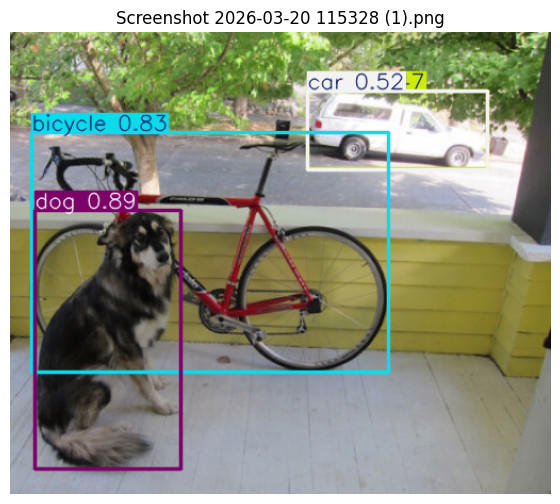

Screenshot 2026-03-20 115328 (1).png: 4 object(s) detected
   → dog (88.6%)
   → bicycle (83.0%)
   → car (52.1%)
   → truck (46.6%)
---


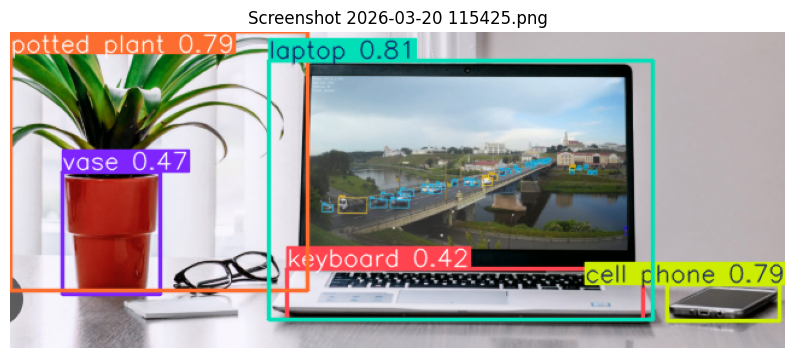

Screenshot 2026-03-20 115425.png: 5 object(s) detected
   → laptop (80.8%)
   → cell phone (79.1%)
   → potted plant (78.7%)
   → vase (47.1%)
   → keyboard (41.7%)
---


In [ ]:
print("Upload multiple images — all will be detected!")
uploaded = files.upload()

for filename in uploaded.keys():
    img_array = np.frombuffer(uploaded[filename], dtype=np.uint8)
    img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)

    results = model.predict(source=img, conf=0.35, iou=0.45,
                            save=False, verbose=False)
    annotated = results[0].plot(line_width=2)

    plt.figure(figsize=(10, 6))
    plt.imshow(annotated[:, :, ::-1])
    plt.axis("off")
    plt.title(filename)
    plt.show()

    boxes = results[0].boxes
    print(f"{filename}: {len(boxes)} object(s) detected")
    for box in boxes:
        print(f"   → {model.names[int(box.cls[0])]} ({float(box.conf[0]):.1%})")
    print("---")

Part 1 — Real-time Object Counter Dashboard

Step 1 — Single capture with live bar chart

In [ ]:
from ultralytics import YOLO
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import numpy as np
import cv2
import matplotlib.pyplot as plt
from collections import Counter

model = YOLO("yolo11n.pt")

def take_photo():
    js = Javascript('''
        async function takePhoto() {
            const div = document.createElement('div');
            const capture = document.createElement('button');
            capture.textContent = '📸 Capture Frame';
            capture.style.padding = '10px 20px';
            capture.style.fontSize = '16px';
            capture.style.margin = '10px';
            capture.style.cursor = 'pointer';
            capture.style.background = '#4CAF50';
            capture.style.color = 'white';
            capture.style.border = 'none';
            capture.style.borderRadius = '8px';
            const video = document.createElement('video');
            video.style.display = 'block';
            video.style.width = '100%';
            video.style.maxWidth = '640px';
            video.setAttribute('playsinline', '');
            const stream = await navigator.mediaDevices.getUserMedia({video: true});
            document.body.appendChild(div);
            div.appendChild(video);
            div.appendChild(capture);
            video.srcObject = stream;
            await video.play();
            await new Promise((resolve) => capture.onclick = resolve);
            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);
            stream.getTracks().forEach(t => t.stop());
            div.remove();
            return canvas.toDataURL('image/jpeg', 0.92);
        }
        takePhoto()
    ''')
    display(js)
    data = eval_js('takePhoto()')
    binary = b64decode(data.split(',')[1])
    img_array = np.frombuffer(binary, dtype=np.uint8)
    return cv2.imdecode(img_array, cv2.IMREAD_COLOR)

print("Ready! Click the button to capture.")

Ready! Click the button to capture.


Step 2 — Detection + dashboard display

<IPython.core.display.Javascript object>

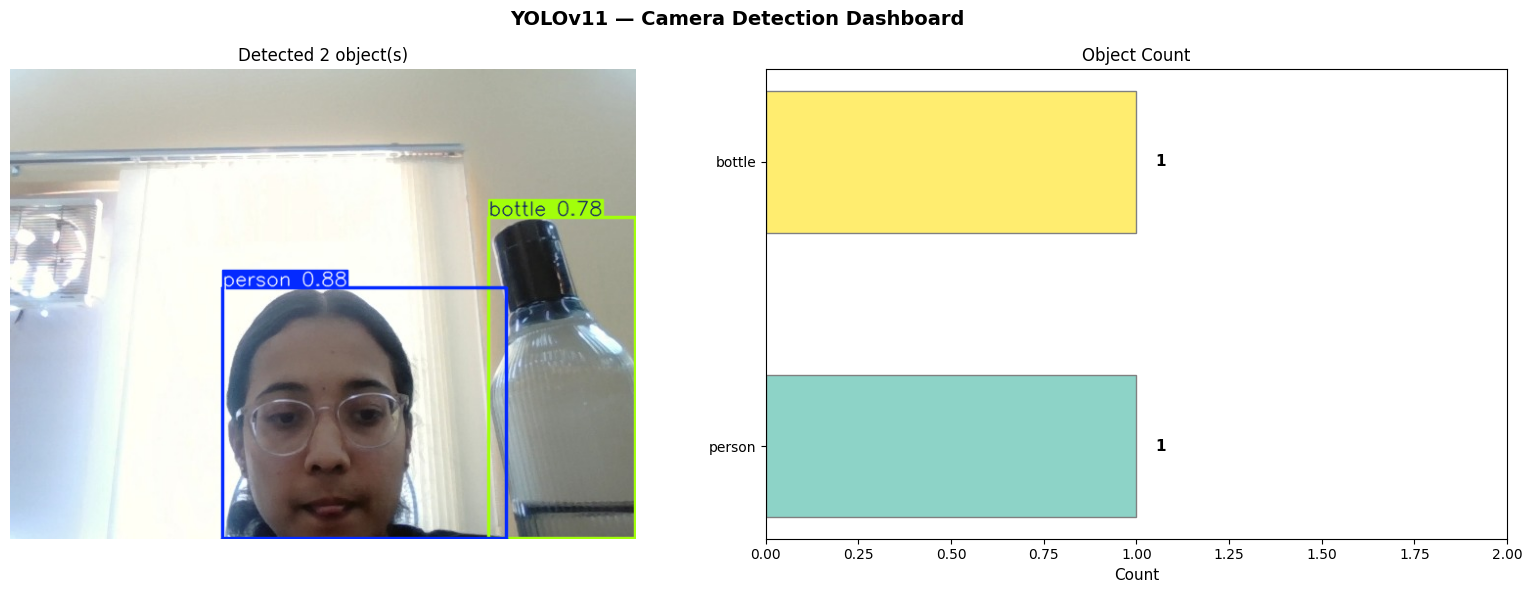


📊 Detection Summary:
------------------------------
   person               : 1
   bottle               : 1
------------------------------
   Total objects : 2


In [ ]:
def run_dashboard(source_img, title="YOLOv11 Detection Dashboard"):
    results = model.predict(
        source=source_img,
        conf=0.35,
        iou=0.45,
        save=False,
        verbose=False
    )

    annotated = results[0].plot(line_width=2)
    boxes = results[0].boxes

    # Count detections per class
    labels = [model.names[int(b.cls[0])] for b in boxes]
    counts = Counter(labels)

    # --- Plot dashboard ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    # Left: annotated image
    ax1.imshow(annotated[:, :, ::-1])
    ax1.axis("off")
    ax1.set_title(f"Detected {len(boxes)} object(s)", fontsize=12)

    # Right: bar chart
    if counts:
        classes = list(counts.keys())
        values  = list(counts.values())
        colors  = plt.cm.Set3(np.linspace(0, 1, len(classes)))

        bars = ax2.barh(classes, values, color=colors, edgecolor='gray', height=0.5)
        ax2.set_xlabel("Count", fontsize=11)
        ax2.set_title("Object Count", fontsize=12)
        ax2.set_xlim(0, max(values) + 1)

        # Add count labels on bars
        for bar, val in zip(bars, values):
            ax2.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                     str(val), va='center', fontsize=11, fontweight='bold')
    else:
        ax2.text(0.5, 0.5, "Nothing detected\nTry better lighting",
                 ha='center', va='center', fontsize=12,
                 transform=ax2.transAxes, color='gray')
        ax2.axis("off")

    plt.tight_layout()
    plt.show()

    # Print summary
    print("\n📊 Detection Summary:")
    print("-" * 30)
    if counts:
        for label, count in sorted(counts.items(), key=lambda x: -x[1]):
            print(f"   {label:20s} : {count}")
    else:
        print("   No objects detected")
    print("-" * 30)
    print(f"   Total objects : {len(boxes)}")

# --- Run with camera ---
frame = take_photo()
run_dashboard(frame, "YOLOv11 — Camera Detection Dashboard")

Part 2 — Video File Upload + Object Detection

Step 1 — Upload and process video


In [ ]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

print("Upload a video file (mp4 / avi / mov)...")
uploaded = files.upload()
video_filename = list(uploaded.keys())[0]
print(f"Uploaded: {video_filename}")

Upload a video file (mp4 / avi / mov)...


Saving 6325848-hd_1920_1080_25fps.mp4 to 6325848-hd_1920_1080_25fps.mp4
Uploaded: 6325848-hd_1920_1080_25fps.mp4


Step 2 — Run detection on every frame

In [ ]:
import os

cap = cv2.VideoCapture(video_filename)

# Get video properties
fps    = int(cap.get(cv2.CAP_PROP_FPS)) or 25
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print(f"Video: {width}x{height} | {fps} FPS | {total} frames")

# Output video writer
out_path = "detected_" + video_filename
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(out_path, fourcc, fps, (width, height))

all_labels = []     # track every detection
frame_count = 0
preview_frames = [] # save a few frames to preview

print("Processing frames... this may take a minute ⏳")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1

    # Run detection
    results = model.predict(
        source=frame,
        conf=0.35,
        iou=0.45,
        save=False,
        verbose=False
    )

    annotated = results[0].plot(line_width=2)
    out.write(annotated)

    # Collect labels
    for box in results[0].boxes:
        all_labels.append(model.names[int(box.cls[0])])

    # Save every 30th frame for preview
    if frame_count % 30 == 0:
        preview_frames.append(annotated.copy())

    # Progress update every 50 frames
    if frame_count % 50 == 0:
        print(f"  Processed {frame_count}/{total} frames...")

cap.release()
out.release()

print(f"\nDone! Processed {frame_count} frames.")
print(f"Output saved as: {out_path}")

Video: 1920x1080 | 25 FPS | 402 frames
Processing frames... this may take a minute ⏳
  Processed 50/402 frames...
  Processed 100/402 frames...
  Processed 150/402 frames...
  Processed 200/402 frames...
  Processed 250/402 frames...
  Processed 300/402 frames...
  Processed 350/402 frames...
  Processed 400/402 frames...

Done! Processed 402 frames.
Output saved as: detected_6325848-hd_1920_1080_25fps.mp4



Step 4 — Video summary dashboard

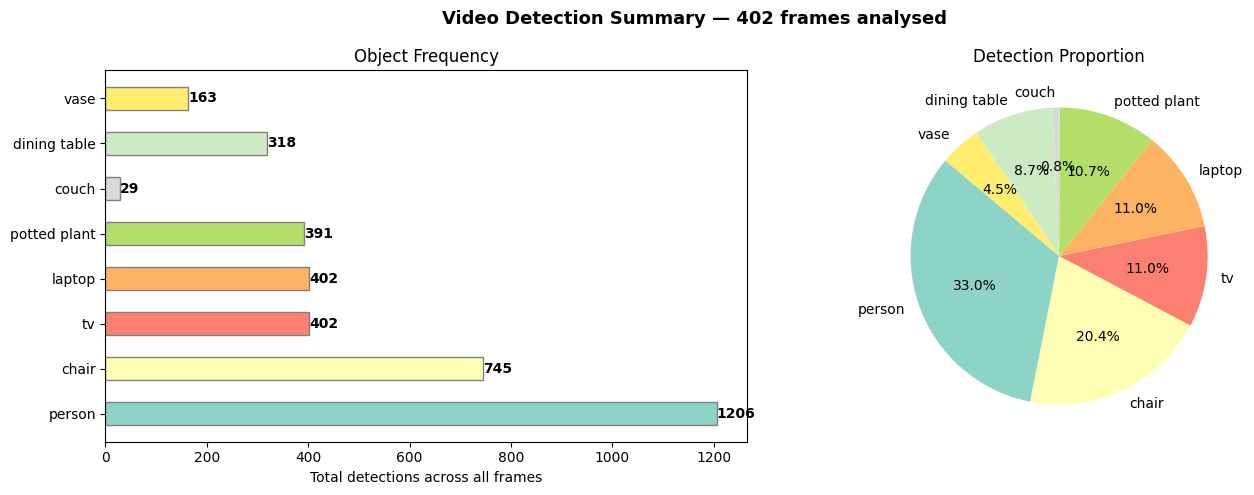


📊 Full Summary:
-----------------------------------
   person               : 1206 detections
   chair                : 745 detections
   tv                   : 402 detections
   laptop               : 402 detections
   potted plant         : 391 detections
   dining table         : 318 detections
   vase                 : 163 detections
   couch                : 29 detections
-----------------------------------
   Total detections : 3656


In [ ]:
from collections import Counter

counts = Counter(all_labels)

if counts:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Video Detection Summary — {frame_count} frames analysed",
                 fontsize=13, fontweight='bold')

    # Bar chart
    labels_list  = list(counts.keys())
    values_list  = list(counts.values())
    colors = plt.cm.Set3(np.linspace(0, 1, len(labels_list)))

    bars = ax1.barh(labels_list, values_list, color=colors,
                    edgecolor='gray', height=0.5)
    ax1.set_xlabel("Total detections across all frames")
    ax1.set_title("Object Frequency")
    for bar, val in zip(bars, values_list):
        ax1.text(bar.get_width() + 0.3,
                 bar.get_y() + bar.get_height() / 2,
                 str(val), va='center', fontweight='bold')

    # Pie chart
    ax2.pie(values_list, labels=labels_list, autopct='%1.1f%%',
            colors=colors, startangle=140)
    ax2.set_title("Detection Proportion")

    plt.tight_layout()
    plt.show()

    print("\n📊 Full Summary:")
    print("-" * 35)
    for label, count in sorted(counts.items(), key=lambda x: -x[1]):
        print(f"   {label:20s} : {count} detections")
    print("-" * 35)
    print(f"   Total detections : {sum(counts.values())}")
else:
    print("No objects detected in video — try lower conf=0.25")

Gradio App

In [ ]:
!pip install gradio ultralytics -q

In [ ]:
import gradio as gr
from ultralytics import YOLO
import cv2
import numpy as np
from PIL import Image
from collections import Counter
import pandas as pd
import os
import tempfile

# Load model once
model = YOLO("yolo11n.pt")

# ─────────────────────────────────────────
# Helper: run detection on any image array
# ─────────────────────────────────────────
def detect_image(img_array, conf):
    results = model.predict(
        source=img_array,
        conf=conf,
        iou=0.45,
        save=False,
        verbose=False
    )
    annotated = results[0].plot(line_width=2)
    annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

    boxes = results[0].boxes
    labels = [model.names[int(b.cls[0])] for b in boxes]
    confs  = [round(float(b.conf[0]), 2) for b in boxes]
    counts = Counter(labels)

    # Summary text
    if labels:
        top_class = counts.most_common(1)[0][0]
        avg_conf  = round(sum(confs) / len(confs), 2)
        summary   = f"✅ {len(boxes)} object(s) detected\n"
        summary  += f"🏆 Top class: {top_class}\n"
        summary  += f"📊 Avg confidence: {avg_conf}\n\n"
        summary  += "\n".join([f"  → {l:20s} {c:.0%}" for l, c in zip(labels, confs)])
    else:
        summary = "❌ Nothing detected — try lowering confidence or improve lighting"

    return annotated_rgb, summary


# ─────────────────────────────────────────
# Tab 1: Camera
# ─────────────────────────────────────────
def camera_detect(camera_img, conf):
    if camera_img is None:
        return None, "No image captured yet"
    img_array = np.array(camera_img)
    img_bgr   = cv2.cvtColor(img_array, cv2.COLOR_RGB2BGR)
    return detect_image(img_bgr, conf)


# ─────────────────────────────────────────
# Tab 2: Image Upload
# ─────────────────────────────────────────
def image_detect(uploaded_img, conf):
    if uploaded_img is None:
        return None, "Please upload an image"
    img_array = np.array(uploaded_img)
    img_bgr   = cv2.cvtColor(img_array, cv2.COLOR_RGB2BGR)
    return detect_image(img_bgr, conf)


# ─────────────────────────────────────────
# Tab 3: Video Upload
# ─────────────────────────────────────────
def video_detect(video_path, conf):
    if video_path is None:
        return None, None, "Please upload a video"

    cap    = cv2.VideoCapture(video_path)
    fps    = int(cap.get(cv2.CAP_PROP_FPS)) or 25
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # Output video
    out_path = tempfile.mktemp(suffix=".mp4")
    fourcc   = cv2.VideoWriter_fourcc(*"mp4v")
    out      = cv2.VideoWriter(out_path, fourcc, fps, (width, height))

    all_detections = []
    frame_count    = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        frame_count += 1

        results  = model.predict(source=frame, conf=conf,
                                 iou=0.45, save=False, verbose=False)
        annotated = results[0].plot(line_width=2)
        out.write(annotated)

        for box in results[0].boxes:
            all_detections.append({
                "frame"     : frame_count,
                "object"    : model.names[int(box.cls[0])],
                "confidence": round(float(box.conf[0]), 3)
            })

    cap.release()
    out.release()

    # Build summary
    if all_detections:
        df     = pd.DataFrame(all_detections)
        counts = Counter(df["object"].tolist())
        top    = counts.most_common(1)[0][0]

        summary  = f"✅ Processed {frame_count} frames\n"
        summary += f"🔍 Total detections: {len(all_detections)}\n"
        summary += f"🏆 Most seen: {top} ({counts[top]} times)\n\n"
        summary += "─" * 30 + "\n"
        for label, cnt in sorted(counts.items(), key=lambda x: -x[1]):
            summary += f"  {label:20s}: {cnt}\n"

        # Save CSV
        csv_path = tempfile.mktemp(suffix=".csv")
        df.to_csv(csv_path, index=False)
    else:
        summary  = "❌ No objects detected — try lowering confidence"
        csv_path = None

    return out_path, csv_path, summary


# ─────────────────────────────────────────
# Build Gradio UI
# ─────────────────────────────────────────
with gr.Blocks(title="YOLOv11 Object Detector", theme=gr.themes.Soft()) as app:

    gr.Markdown("""
    # 🎯 YOLOv11 Object Detection
    Detect objects in real-time via **camera**, **image upload**, or **video upload**
    """)

    with gr.Tabs():

        # ── Tab 1: Camera ──
        with gr.Tab("📷 Camera"):
            gr.Markdown("### Capture from webcam and detect objects")
            with gr.Row():
                cam_input  = gr.Image(sources=["webcam"], type="pil",
                                      label="Camera feed", mirror_webcam=True)
                cam_output = gr.Image(label="Detection result")
            cam_conf = gr.Slider(0.1, 0.9, value=0.35, step=0.05,
                                 label="Confidence threshold")
            cam_btn  = gr.Button("🔍 Detect", variant="primary")
            cam_text = gr.Textbox(label="Detection summary", lines=6)

            cam_btn.click(
                fn=camera_detect,
                inputs=[cam_input, cam_conf],
                outputs=[cam_output, cam_text]
            )

        # ── Tab 2: Image Upload ──
        with gr.Tab("🖼️ Image upload"):
            gr.Markdown("### Upload any image and detect objects")
            with gr.Row():
                img_input  = gr.Image(type="pil", label="Upload image")
                img_output = gr.Image(label="Detection result")
            img_conf = gr.Slider(0.1, 0.9, value=0.35, step=0.05,
                                 label="Confidence threshold")
            img_btn  = gr.Button("🔍 Detect", variant="primary")
            img_text = gr.Textbox(label="Detection summary", lines=6)

            img_btn.click(
                fn=image_detect,
                inputs=[img_input, img_conf],
                outputs=[img_output, img_text]
            )

        # ── Tab 3: Video Upload ──
        with gr.Tab("🎬 Video upload"):
            gr.Markdown("### Upload a video — every frame gets detected")
            vid_input = gr.Video(label="Upload video (mp4/avi/mov)")
            vid_conf  = gr.Slider(0.1, 0.9, value=0.35, step=0.05,
                                  label="Confidence threshold")
            vid_btn   = gr.Button("🎬 Process video", variant="primary")

            with gr.Row():
                vid_output = gr.Video(label="Output video with detections")
                vid_csv    = gr.File(label="Download detection log (CSV)")

            vid_text = gr.Textbox(label="Video summary", lines=8)

            vid_btn.click(
                fn=video_detect,
                inputs=[vid_input, vid_conf],
                outputs=[vid_output, vid_csv, vid_text]
            )

# ─────────────────────────────────────────
# Launch
# ─────────────────────────────────────────
app.launch(share=True)  # share=True gives a public link!

/tmp/ipykernel_1086/315584807.py:138: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(title="YOLOv11 Object Detector", theme=gr.themes.Soft()) as app:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2fe53cc877d48050b2.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
